# Forecast Error Analysis and Wind Generation Reliability

## Goal of the Analysis

The purpose of this analysis is to evaluate the accuracy of wind power generation forecasts and to understand the reliability of wind power as a source of electricity.

Wind power generation is highly dependent on weather conditions, which makes accurate forecasting important for power grid planning and electricity market operations. Forecast errors can lead to supply-demand imbalances and may require additional backup generation from other sources.

In this notebook, I am analyzing historical wind generation data and corresponding forecast data for January 2024 in order to understand the error characteristics of the forecasting model.

The analysis focuses on two main objectives:

1. **Forecast Error Analysis**
   - Measure how accurate the wind generation forecasts are.
   - Compute error metrics such as Mean Absolute Error (MAE), median error and P99 error.
   - Analyze how forecast accuracy changes with different forecast horizons.
   - Examine whether forecast errors vary across different times of the day.

2. **Wind Generation Reliability**
   - Analyze historical wind generation levels.
   - Study the distribution and variability of wind power output.
   - Estimate how much wind power can be reliably expected to meet electricity demand.

The goal is to derive insights about forecast performance and provide a data-driven recommendation for the reliable contribution of wind power to electricity supply.


## 2. Data Description

This analysis uses two datasets obtained from the Elexon BMRS API: the **actual wind generation dataset** and the **wind generation forecast dataset**. These datasets contain information about the amount of electricity generated by wind power and the predicted values produced by forecasting models.

### 2.1 Actual Wind Generation Data

The actual generation dataset contains the measured wind power generation at specific time intervals. Each record represents the amount of electricity generated by wind turbines during a settlement period.

Key columns in this dataset include:

- **startTime**  
  The timestamp representing the end of the settlement period when the wind generation was measured. This represents the *target time* for which power generation is recorded.

- **generation**  
  The actual amount of electricity generated from wind power during that period, measured in **megawatts (MW)**.

- **fuelType**  
  The type of fuel used for generation. In this analysis, only records with `fuelType = WIND` are used.


---

### 2.2 Wind Generation Forecast Data

The forecast dataset contains predictions of future wind power generation. These forecasts are created at different times before the target generation time.

Key columns in this dataset include:

- **startTime**  
  The target time for which the wind generation is being predicted.

- **publishTime**  
  The time at which the forecast was generated and published.

- **generation**  
  The predicted wind power generation for the corresponding target time, measured in **MW**.


---

### Relationship Between Actual and Forecast Data

For each target time (`startTime`), there may be several forecasts generated at different `publishTime` values. In this analysis, we follow the assignment requirement of selecting the **latest forecast that was created at least H hours before the target time**, where **H represents the forecast horizon**.

This allows us to simulate realistic forecasting scenarios where predictions must be made some hours in advance before the actual generation occurs.

## 3. Forecast Error Analysis

To evaluate the performance of the wind generation forecasting model, we analyze the difference between the **actual generation values** and the **forecasted generation values**.

Forecast error is defined as:

Error = Actual Generation − Forecast Generation

A positive error indicates that the forecast underestimated the actual wind generation, while a negative error indicates that the forecast overestimated generation.

To better understand the magnitude and distribution of forecast errors, we compute the following metrics:

**Mean Absolute Error (MAE)**  
MAE represents the average magnitude of forecast errors regardless of direction. It provides an overall measure of typical forecast accuracy.

**Median Absolute Error**  
The median error represents the middle value of the absolute error distribution. It is less sensitive to extreme outliers than the mean and therefore gives a robust measure of typical forecast error.

**P99 Error (99th Percentile Error)**  
The P99 error represents the value below which 99% of forecast errors fall. This metric helps us understand extreme forecast errors and the potential worst-case deviations between forecasted and actual wind generation.

These metrics together provide insight into both the **typical forecast performance** and the **extreme error scenarios** of the forecasting model.

In [12]:
import sys
import os
import pandas as pd

# Add project root to path
sys.path.append(os.path.abspath(".."))

from src.forecast_utils import prepare_forecasts, get_forecast_for_horizon


# Load datasets
actuals = pd.read_csv("../data/actuals.csv", parse_dates=["startTime"])
forecasts = pd.read_csv("../data/forecasts.csv", parse_dates=["startTime","publishTime"])

# Prepare forecasts
forecasts = prepare_forecasts(forecasts)

# Select forecasts with 4-hour horizon
df = get_forecast_for_horizon(actuals, forecasts, horizon_hours=4)

# Compute errors
df["error"] = df["generation_actual"] - df["generation_forecast"]
df["abs_error"] = df["error"].abs()

# Calculate metrics
mae = df["abs_error"].mean()
median_error = df["abs_error"].median()
p99_error = df["abs_error"].quantile(0.99)

print("Mean Absolute Error (MAE):", mae)
print("Median Absolute Error:", median_error)
print("P99 Error:", p99_error)

Mean Absolute Error (MAE): 1838.1313969571231
Median Absolute Error: 1483.0
P99 Error: 6157.899999999989


/Users/chinnisreeaddagalla/Desktop/Forecast_Project/src/forecast_utils.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecasts["horizon_hrs"] = (


### Interpretation of Forecast Errors

The Mean Absolute Error (MAE) is approximately **1838 MW**, which indicates that on average the forecast differs from the actual wind generation by about 1.8 GW.

The median absolute error is **1483 MW**, which is lower than the mean error. This suggests that most forecast errors are relatively moderate, but some large forecasting mistakes increase the overall average error.

The P99 error is **6157 MW** meaning that 99% of forecast errors are below approximately 6.1 GW. This highlights that while the model performs reasonably well in most cases, extreme forecast errors can still occur due to the highly variable nature of wind generation and changing weather conditions.

Overall, the results suggest that wind forecasts provide useful guidance but still contain significant uncertainty especially in extreme conditions.

## 4. Error vs Forecast Horizon

Forecast accuracy often depends on how far in advance the forecast is made. 
Shorter forecast horizons generally produce more accurate predictions because 
less uncertainty exists in the weather conditions affecting wind generation.

To analyze this effect, we compute forecast errors for multiple forecast horizons 
ranging from 1 hour to 48 hours.

For each horizon value, we select the latest forecast that was available before 

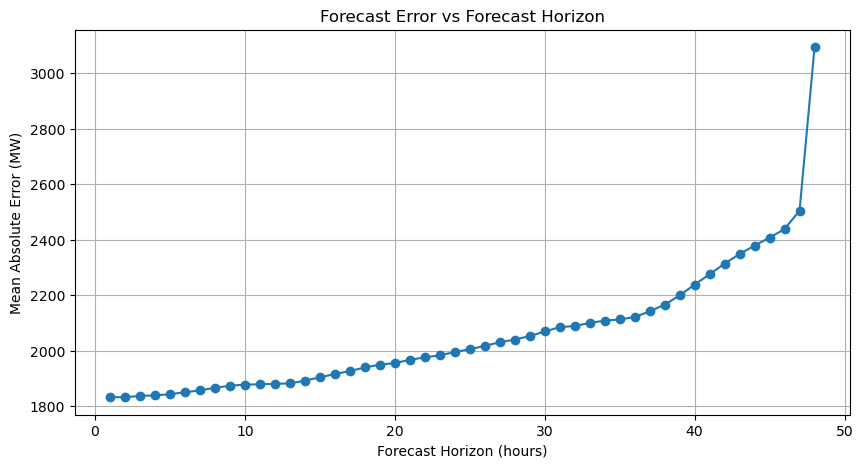

In [13]:
import matplotlib.pyplot as plt

horizons = range(1, 49)
mae_values = []

for h in horizons:
    
    df_h = get_forecast_for_horizon(actuals, forecasts, horizon_hours=h)
    
    error = (df_h["generation_actual"] - df_h["generation_forecast"]).abs()
    
    mae_values.append(error.mean())

plt.figure(figsize=(10,5))
plt.plot(horizons, mae_values, marker='o')

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Mean Absolute Error (MW)")
plt.title("Forecast Error vs Forecast Horizon")

plt.grid(True)
plt.show()


### Observations

The results indicate that forecast error increases as the forecast horizon becomes longer. Short-term forecasts (1–4 hours ahead) are generally more accurate because they use more recent weather information.

When the forecast horizon increases to 24–48 hours, uncertainty in weather conditions grows, which leads to larger prediction errors. This pattern is expected in wind forecasting since wind behavior can change quickly.

## 5. Error vs Time of Day

Wind generation patterns can vary throughout the day due to changes in weather conditions such as temperature, pressure and atmospheric circulation. As a result the accuracy of wind power forecasts may also vary depending on the time of day.

For this I analyzed forecast errors across different hours of the day. For each target time I extract the hour from the timestamp and compute the average forecast error for that hour.

This analysis helps identify whether certain periods of the day experience larger forecasting errors compared to others.

In [14]:
import matplotlib.pyplot as plt

# Use the same dataframe used earlier (example: horizon = 4 hours)
df_hour = get_forecast_for_horizon(actuals, forecasts, horizon_hours=4)

# Compute absolute error
df_hour["abs_error"] = (df_hour["generation_actual"] - df_hour["generation_forecast"]).abs()

# Extract hour of day
df_hour["hour"] = df_hour["startTime"].dt.hour

# Average error per hour
hourly_error = df_hour.groupby("hour")["abs_error"].mean()

hourly_error

hour
0     1856.800000
1     1883.400000
2     2044.666667
3     2060.866667
4     2192.233333
5     2094.933333
6     1944.133333
7     1781.833333
8     1696.066667
9     1647.000000
10    1654.100000
11    2261.500000
12    1797.566667
13    1897.900000
14    1702.533333
15    1552.366667
16    1554.233333
17    1596.200000
18    1637.166667
19    1912.966667
20    1923.833333
21    1806.806452
22    1838.032258
23    1780.967742
Name: abs_error, dtype: float64

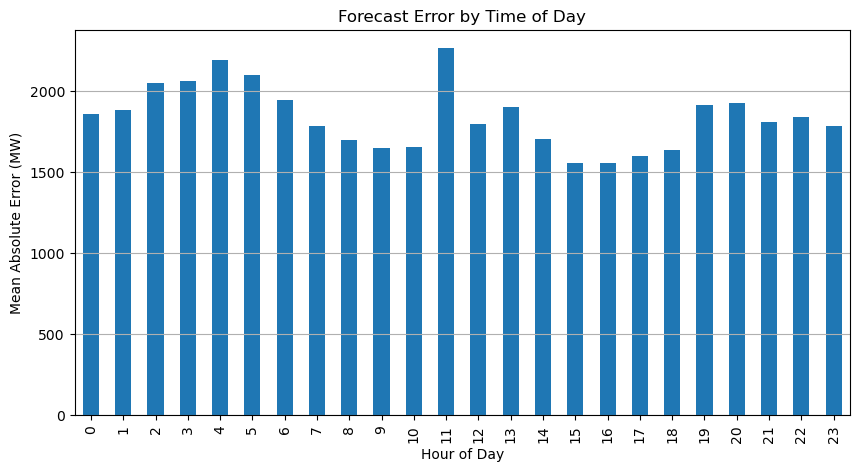

In [15]:
plt.figure(figsize=(10,5))

hourly_error.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error (MW)")
plt.title("Forecast Error by Time of Day")

plt.grid(axis="y")

plt.show()

### Observations

The results show that forecast errors vary across different hours of the day. Certain hours exhibit slightly higher errors, which may be due to changes in wind patterns during those periods.

Wind generation is influenced by atmospheric conditions that can fluctuate throughout the day. As a result, forecasting models may perform better during some hours and less accurately during others.

Overall, the variation suggests that time-of-day effects may influence forecast accuracy, although the differences are not extremely large.

## 6. Wind Generation Reliability

Wind power generation is highly dependent on weather conditions, which makes it inherently variable. In order to understand how reliably wind power can contribute to electricity supply, we analyze the historical distribution of actual wind generation values.

By examining the distribution of generation levels, we can estimate how much wind power is available most of the time. One useful way to evaluate reliability is through **percentile analysis**.

For example:

- The **10th percentile** represents the level of generation that is exceeded 90% of the time.
- The **50th percentile (median)** represents the typical generation level.
- The **90th percentile** represents periods of high wind generation.

Using these statistics, we can estimate a conservative level of wind generation that can be reliably expected to contribute to electricity demand.

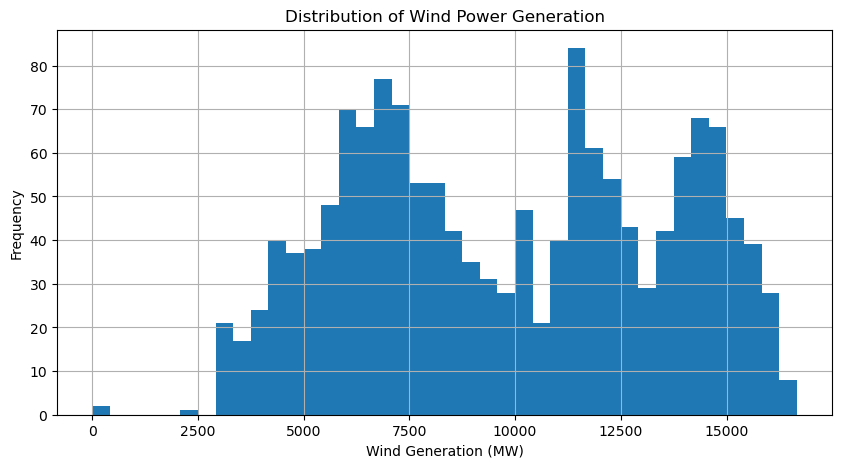

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

actuals["generation"].hist(bins=40)

plt.xlabel("Wind Generation (MW)")
plt.ylabel("Frequency")
plt.title("Distribution of Wind Power Generation")

plt.grid(True)

plt.show()

In [17]:
p10 = actuals["generation"].quantile(0.10)
p50 = actuals["generation"].quantile(0.50)
p90 = actuals["generation"].quantile(0.90)

print("10th percentile generation:", p10)
print("Median generation:", p50)
print("90th percentile generation:", p90)

10th percentile generation: 5087.900000000001
Median generation: 9863.5
90th percentile generation: 14809.6


### Interpretation

The distribution of wind generation shows significant variability, which is expected because wind speeds fluctuate depending on weather conditions.

The 10th percentile generation level represents the amount of wind power that is available at least 90% of the time. This provides a conservative estimate of the reliable contribution of wind power to electricity supply.

The median generation indicates the typical wind output, while the 90th percentile represents periods with very strong wind conditions.

Since electricity systems require reliable supply, the lower percentile values are often used to estimate dependable generation capacity.

## 7. Final Recommendation: Reliable Wind Power Capacity

Based on the historical wind generation data, we estimate the amount of wind power that can be reliably expected to meet electricity demand.

The analysis shows that the **10th percentile generation level is approximately 5087.9 MW**, meaning that wind generation exceeds this value for about **90% of the observed time periods**.

Because electricity systems require dependable supply, this percentile provides a conservative estimate of the wind capacity that can be considered reliably available.

Therefore, we recommend that approximately **5,088 MW of wind power** can be considered reliably available to support electricity demand under typical operating conditions.

This recommendation is based on historical generation patterns and reflects the inherent variability of wind power while ensuring a cautious estimate of dependable capacity.